In [61]:
import numpy as np
from scipy.linalg import expm, eigh
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from functools import reduce


def pauli():
    I = np.array([[1, 0],[0, 1]], dtype=complex)
    X = np.array([[0, 1],[1, 0]], dtype=complex)
    Y = np.array([[0, -1j],[1j, 0]], dtype=complex)
    Z = np.array([[1, 0],[0,-1]], dtype=complex)
    return I, X, Y, Z

# def op_site(op, site, N):
#     I, _, _, _ = pauli()
#     ops = [I]*N
#     ops[site] = op
#     M = ops[0]
#     for k in range(1, N):
#         M = np.kron(M, ops[k])
#     return M

def tensor_prod(op_list):
    return reduce(np.kron, op_list)

def Hd_ZZ(N, J=1.0):
    I, _, _, Z = pauli()
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    for j in range(N-1):
        ops = [I] * N
        ops[j] = Z
        ops[j+1] = Z
        term = reduce(np.kron, ops)

        H += J * term
        # H += J * (op_site(Z, j, N) @ op_site(Z, j+1, N))
    return H

def Hc_sumX(N, h=1.0):
    I, X, _, _ = pauli()
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    for j in range(N):
        ops = [I] * N
        ops[j] = X
        term = tensor_prod(ops)

        H += term
        # H += op_site(X, j, N)
    return H

def ground_state(H):
    # E, V = eigh((H + H.conj().T)/2)
    E, V = eigh(H , subset_by_index=[0, 0])
    return E[0], V[:,0]
    # dim = 2**N
    # v0 = np.ones(dim, dtype = float)
    # E, V = eigsh(H, k=1, which='SA', v0=v0)
    # return E[0], V[:,0]/ np.linalg.norm(V[:,0])

def get_schedule(t, T, alpha=1.0):
    s = (t/T)**alpha
    return 1-s, s

from scipy.linalg import eigh
import numpy as np

# def check_degeneracy(H, tolerance=1e-10):
#     """
#     Kiểm tra xem trạng thái cơ bản có suy biến hay không.
#     Trả về: (Có suy biến?, Độ chênh lệch năng lượng, Các trị riêng)
#     """
#     # Lấy 2 trị riêng thấp nhất (Index 0 và 1)
#     vals = eigh(H, subset_by_index=[0, 1], eigvals_only=True)
#
#     E0 = vals[0]
#     E1 = vals[1]
#     gap = E1 - E0
#
#     is_degenerate = gap < tolerance
#
#     print(f"--- Kiểm tra suy biến ---")
#     print(f"E0 = {E0:.10f}")
#     print(f"E1 = {E1:.10f}")
#     print(f"Gap = {gap:.10e}")
#
#     if is_degenerate:
#         print("=> KẾT LUẬN: Trạng thái cơ bản SUY BIẾN (Degenerate).")
#     else:
#         print("=> KẾT LUẬN: Trạng thái cơ bản KHÔNG SUY BIẾN (Unique).")
#
#     return is_degenerate, gap
def Hc_spectrum(N):
     Hc = Hc_sumX(N)
     evals = eigh(Hc, eigvals_only=True)
     evals_rounded = np.round(evals, 5)
     unique_energies, counts = np.unique(evals_rounded, return_counts=True)

    print(f"Tổng số trạng thái (Dimension): {2**N}")
    print("Các mức năng lượng (Energy Levels):")
    print(f"{'Energy (E)':<15} | {'Degeneracy (Số lượng)':<20} | {'Tỷ lệ %':<10}")
    print("-" * 55)

    for E, count in zip(unique_energies, counts):
        percentage = (count / (2**N)) * 100
        print(f"{E:<15.1f} | {count:<20} | {percentage:.1f}%")

    print(f"- Năng lượng thấp nhất (Min): {-N}")
    print(f"- Năng lượng cao nhất (Max):  {N}")


# def s_of_t(t, T, alpha=1.0):
#     s = (t/T)**alpha
#     return min(max(s, 0.0), 1.0)
#
# def A(t, T, alpha=1.0):
#     return 1 - s_of_t(t, T, alpha)
#
# def B(t, T, alpha=1.0):
#     return s_of_t(t, T, alpha)

def qfi_during_anneal(N=4, J = 1.0, h = 0.2, T = 10.0, K = 1000, alpha = 1.0, return_trace =True):
    Hd = Hd_ZZ(N, J)
    Xsum = Hc_sumX(N)

    E0, psi0 = ground_state(Hd)
    dt = T/K
    dim = 2**N
    U = np.eye(dim, dtype=complex)
    G = np.zeros((dim, dim), dtype=complex)

    times = []
    FQs = []

    for k in range(K):
        t = k*dt

        _, B_t = get_schedule(t, T , alpha)
        dHdh = B_t * Xsum

        term = U.conj().T @ dHdh @ U
        G += term * dt

        tm = t + 0.5 * dt
        A_mid, B_mid = get_schedule(tm, T , alpha)
        Hmid = A_mid * Hd + B_mid * (h * Xsum)

        Ustep = expm(-1j * Hmid * dt)
        U = Ustep @ U

        if return_trace and (k % max(1, K//100) == 0):
            G_psi = G @ psi0
            mean = np.vdot(psi0, G_psi)
            mean_sq = np.vdot(psi0, G @ G_psi)

            var = mean_sq - (mean * np.conj(mean))
            FQ = 4 * np.real(var)

            times.append(t)
            FQs.append(FQ)

    G_psi = G @ psi0
    mean = np.vdot(psi0, G_psi)
    mean_sq = np.vdot(psi0, G @ G_psi)
    var = mean_sq - (mean * np.conj(mean))
    FQ_T = 4 * np.real(var)

    if return_trace:
        times.append(t)
        FQs.append(FQ_T)
        return FQ_T, (np.array(times), np.array(FQs))
    else:
        return FQ_T, None

# def evolve(N, J, h, T, K, alpha):
#     Hd = Hd_ZZ(N, J)
#     Hc = Hc_sumX(N)
#     Hp = h * Hc
#
#     _, psi = ground_state(Hd)
#     psi = psi.astype(complex)
#
#     dt = T/K
#     print("Tiến hoá trạng thái...")
#
#     for k in range(K):
#         tm = (k+0.5)*dt
#         H_mid = A(tm, T, alpha)*Hd + B(tm, T, alpha)*Hp
#         U = expm(-1j * H_mid * dt)
#         psi = U @ psi
#
#     return psi
#
# def energy_distribution(psi_T, N):
#     Hc = Hc_sumX(N)
#     energies, states = eigh(Hc)
#
#     amps = states.conj().T @ psi_T
#     probs = np.abs(amps)**2
#
#     rounded = np.round(energies, 5)
#     unique_E = np.unique(rounded)
#
#     dist = {}
#     for E in unique_E:
#         idx = np.where(rounded == E)
#         dist[E] = np.sum(probs[idx])
#
#     return dist, unique_E

if __name__ == "__main__":
    N = 4
    J = 1.0
    h = 0.2
    T = 10
    K = 2000
    alpha = 1.0

    FQ_T , trace = qfi_during_anneal(N, J, h, T, K, alpha, return_trace=True)
    time_arr, fqs_arr = trace

    Hc_spectrum(N=4)
    # Hd = Hd_ZZ(N=4, J=1.0)
    # check_degeneracy(Hd)

    # --- VẼ ĐỒ THỊ ---
    plt.figure(figsize=(10, 6))

    # Vẽ đường cong
    plt.plot(time_arr, fqs_arr, label=f'N={N}, h={h}', color='b', linewidth=2)

    # Trang trí đồ thị
    plt.title(f'Quantum Fisher Information during Annealing (Alpha={alpha})')
    plt.xlabel('Time (t)')
    plt.ylabel('QFI ($F_Q$)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Hiển thị
    plt.show()



    # psi_T = evolve(N, J, h, T, K, alpha)
    #
    # dist, levels = energy_distribution(psi_T, N)
    #
    # print("\n=== Energy Distribution P(E_k) ===")
    # for E, P in dist.items():
    #     print(f"E = {E:5.1f} : P = {P*100:6.2f}%")
    # print("Tổng xác suất:", np.sum(list(dist.values())))
    #
    # # --- Plot ---
    # plt.figure(figsize=(10,5))
    # plt.bar(list(dist.keys()), list(dist.values()), width=0.5, edgecolor='black')
    # plt.xlabel("Energy eigenvalue $E_k$ of $H_c = \\sum X_j$")
    # plt.ylabel("Probability $P(E_k)$")
    # plt.title(f"Energy distribution for ψ(T={T})")
    # plt.grid(axis='y', linestyle='--', alpha=0.6)
    # plt.show()


IndentationError: unindent does not match any outer indentation level (<string>, line 103)

In [54]:
def check_initial_degeneracy(N, J):
    print(f"\n--- KIỂM TRA SUY BIẾN CỦA Hd (N={N}) ---")

    # 1. Tạo Hamiltonian ban đầu
    Hd = Hd_ZZ(N, J)

    # 2. Tính toàn bộ phổ năng lượng (tất cả trị riêng)
    # Lưu ý: eigh luôn trả về kết quả đã sắp xếp từ bé đến lớn

    vals, vecs = eigh((Hd + Hd.conj().T)/2)

    # 3. In ra 4 mức năng lượng thấp nhất
    print("Các mức năng lượng thấp nhất (E0, E1, E2, E3):")
    for i in range(4):
        print(f"  Mức {i}: {vals[i]:.6f}")

    # 4. Kiểm tra tự động
    # Nếu E1 rất gần E0 (sai số nhỏ hơn 1e-9) -> Suy biến
    if np.abs(vals[1] - vals[0]) < 1e-9:
        print("=> KẾT LUẬN: Trạng thái cơ bản BỊ SUY BIẾN (Degenerate).")
        print("   Có ít nhất 2 trạng thái cùng có năng lượng thấp nhất.")
    else:
        print("=> KẾT LUẬN: Trạng thái cơ bản DUY NHẤT (Non-degenerate).")

    # 5. (Nâng cao) Xem máy tính đã chọn trạng thái nào?
    # Vì suy biến, máy tính sẽ chọn ngẫu nhiên một tổ hợp tuyến tính.
    # Ta in xác suất của vector psi0 trên cơ sở tính toán (computational basis)
    psi0 = vecs[:, 0]
    probs = np.abs(psi0)**2
    print("\nCấu thành của trạng thái được chọn (Ground State Composition):")
    for i, p in enumerate(probs):
        if p > 0.01: # Chỉ in các thành phần có xác suất đáng kể
            # Chuyển số i thành chuỗi nhị phân (ví dụ 5 -> |0101>)
            binary_str = format(i, f'0{N}b')
            print(f"  |{binary_str}> : {p*100:.1f}%")

# --- CHẠY THỬ TRONG MAIN ---
if __name__ == "__main__":
    N = 2
    J = 1.0

    # Gọi hàm kiểm tra trước khi chạy simulation
    check_initial_degeneracy(N, J)


--- KIỂM TRA SUY BIẾN CỦA Hd (N=2) ---
Các mức năng lượng thấp nhất (E0, E1, E2, E3):
  Mức 0: -1.000000
  Mức 1: -1.000000
  Mức 2: 1.000000
  Mức 3: 1.000000
=> KẾT LUẬN: Trạng thái cơ bản BỊ SUY BIẾN (Degenerate).
   Có ít nhất 2 trạng thái cùng có năng lượng thấp nhất.

Cấu thành của trạng thái được chọn (Ground State Composition):
  |01> : 100.0%


<>:160: SyntaxWarning: invalid escape sequence '\s'
<>:162: SyntaxWarning: invalid escape sequence '\p'
<>:160: SyntaxWarning: invalid escape sequence '\s'
<>:162: SyntaxWarning: invalid escape sequence '\p'
C:\Users\anhduy.truong\AppData\Local\Temp\ipykernel_27480\318222182.py:160: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Energy $E_k$ (Eigenvalue of $H_c = \sum X_j$)")
C:\Users\anhduy.truong\AppData\Local\Temp\ipykernel_27480\318222182.py:162: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Energy Distribution $\psi(T={T})$ in the basis of $H_c$")


Bắt đầu tiến hóa trạng thái: N=4, T=10, K=2000...
Tiến hóa hoàn tất.

Giá trị kỳ vọng <psi(T)| Hc |psi(T)> = -1.892901
Tìm phổ của Hc = sum(X)...

Phân bố xác suất P(E_k) tại T=10:
  E =  -4.0 : P =  27.06%
  E =  -2.0 : P =  45.61%
  E =   0.0 : P =  22.59%
  E =   2.0 : P =   4.39%
  E =   4.0 : P =   0.35%
  Tổng xác suất: 1.00000

Đã lưu biểu đồ phân bố năng lượng vào 'energy_distribution_T10.png'


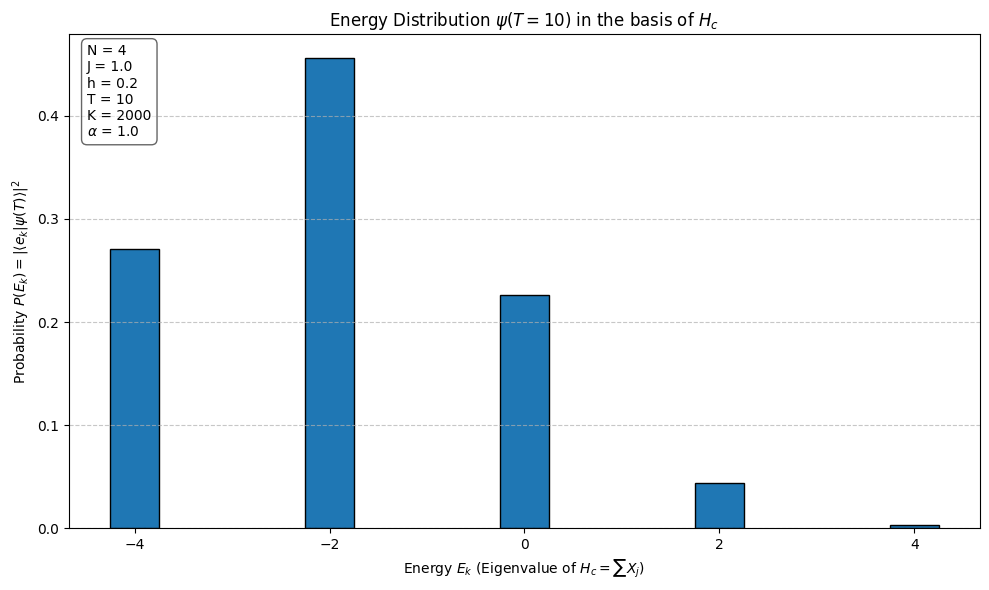

In [6]:
import numpy as np
from scipy.linalg import expm, eigh
import matplotlib.pyplot as plt
import pandas as pd

# ===== (1) CÁC HÀM TIỆN ÍCH (Giống như code gốc) =====

def pauli_mats():
    I = np.array([[1, 0], [0, 1]], dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    return I, X, Y, Z

def op_on_site(single_op, site, N):
    I, _, _, _ = pauli_mats()
    ops = [I]*N
    ops[site] = single_op
    M = ops[0]
    for k in range(1, N):
        M = np.kron(M, ops[k])
    return M

def sum_two_body_ZZ(N, J = 1.0, open_chain = True):
    _, _, _, Z = pauli_mats()
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)
    last = N-1
    pairs = [(j,j+1) for j in range(N-1)]
    if not open_chain:
        pairs.append((last, 0))
    for (j,k) in pairs:
        H += J* (op_on_site(Z, j , N) @ op_on_site(Z, k , N))
    return H

def sum_one_body_X(N):
    _, X, _, _ = pauli_mats()
    dim = 2**N
    Xsum = np.zeros((dim, dim), dtype=complex)
    for j in range(N):
        Xsum += op_on_site(X, j, N)
    return Xsum

def ground_state(H):
    # Hermitize để đảm bảo ổn định số
    H_herm = (H + H.conj().T) / 2
    E, V = eigh(H_herm)
    return E[0], V[:,0]

def s_of_t(t, T, alpha=1.0):
    s = (t/T) ** alpha
    return min(max(s, 0.0),1.0)

def A_of_t(t, T, alpha=1.0):
    return 1.0 - s_of_t(t, T, alpha)

def B_of_t(t, T, alpha=1.0):
    return s_of_t(t, T, alpha)

# ===== (2) HÀM TIẾN HÓA TRẠNG THÁI =====
def evolve_final_state(N, J, h, T, K, alpha):
    """
    Tiến hóa trạng thái từ t=0 đến t=T và trả về trạng thái cuối cùng |psi(T)>.
    """
    # Xây dựng Hamiltonian
    Hd = sum_two_body_ZZ(N, J, open_chain=True)
    Xsum = sum_one_body_X(N)
    Hp = h * Xsum # H_p trong H(t) có chứa 'h'

    # Trạng thái ban đầu |psi(0)>
    E0, psi_t = ground_state(Hd)
    psi_t = psi_t.astype(complex) # Đảm bảo là complex

    dt = T/K

    print(f"Bắt đầu tiến hóa trạng thái: N={N}, T={T}, K={K}...")
    for k in range(K):
        tm = (k + 0.5) * dt # Thời gian điểm giữa

        # Hamiltonian ở điểm giữa
        Hmid = A_of_t(tm, T, alpha) * Hd + B_of_t(tm, T, alpha) * Hp

        # Bước tiến hóa U_step = exp(-i * H_mid * dt)
        Ustep = expm(-1j * Hmid * dt)

        # Cập nhật trạng thái |psi(t+dt)> = U_step |psi(t)>
        psi_t = Ustep @ psi_t

    print("Tiến hóa hoàn tất.")
    return psi_t # Trạng thái cuối cùng |psi(T)>

# ===== (3) SCRIPT CHÍNH ĐỂ TÍNH PHÂN BỐ =====
if __name__ == "__main__":

    # --- (A) Tham số mô phỏng (T=10) ---
    N = 4
    J = 1.0
    h = 0.2
    T = 10    # Thời gian cuối theo yêu cầu
    K = 2000    # Số bước thời gian
    alpha = 1.0

    # --- (B) Bước 1: Lấy trạng thái cuối cùng |psi(T)> ---
    psi_T = evolve_final_state(N, J, h, T, K, alpha)

    # --- (C) Bước 2: Xây dựng H_c và tìm phổ của nó ---
    # H_c là "tổng chuỗi pauli X", không có 'h'
    # Đây là Hamiltonian mà chúng ta muốn đo
    Hc = sum_one_body_X(N)

    # Giá trị kỳ vọng <E> = <psi|Hc|psi> (một con số duy nhất)
    E_expect = np.vdot(psi_T, Hc @ psi_T)
    print(f"\nGiá trị kỳ vọng <psi(T)| Hc |psi(T)> = {E_expect.real:.6f}")

    # Tìm các mức năng lượng (giá trị riêng) E_k và
    # các trạng thái năng lượng (vectơ riêng) |e_k> của Hc
    # energies_c: mảng các E_k
    # states_c: ma trận với các cột là các |e_k>
    print("Tìm phổ của Hc = sum(X)...")
    energies_c, states_c = eigh(Hc)

    # --- (D) Bước 3: Tính xác suất P(E_k) = |<e_k | psi(T)>|^2 ---

    # states_c.conj().T là ma trận với các hàng là <e_k| (bra)
    # Phép nhân ma trận (@) này thực hiện tất cả các phép chiếu cùng lúc
    # prob_vector[k] = |<e_k | psi_T>|^2
    prob_vector = np.abs(states_c.conj().T @ psi_T)**2

    # --- (E) Xử lý và nhóm các kết quả ---
    # Do Hc có thể có suy biến (nhiều trạng thái |e_k> có cùng năng lượng E_k)
    # Chúng ta cần cộng tất cả các xác suất của các trạng thái suy biến đó lại.

    prob_distribution = {}
    # Làm tròn năng lượng để nhóm lại (vd: 0.0 và -0.0000001 là một)
    rounded_energies = np.round(energies_c, 5)

    unique_energies = np.unique(rounded_energies)

    for E_val in unique_energies:
        # Tìm tất cả các index k có cùng mức năng lượng E_val
        indices = np.where(rounded_energies == E_val)
        # Cộng tất cả xác suất P(E_k) tương ứng
        total_prob = np.sum(prob_vector[indices])
        prob_distribution[E_val] = total_prob

    print("\nPhân bố xác suất P(E_k) tại T=10:")
    for E, P in prob_distribution.items():
        print(f"  E = {E:5.1f} : P = {P*100:6.2f}%")

    # Kiểm tra tổng xác suất (phải bằng 1)
    print(f"  Tổng xác suất: {np.sum(list(prob_distribution.values())):.5f}")

    # --- (F) Vẽ biểu đồ ---
    E_vals = list(prob_distribution.keys())
    Probs = list(prob_distribution.values())

    plt.figure(figsize=(10, 6))
    plt.bar(E_vals, Probs, width=0.5, align='center', edgecolor='black')

    plt.xlabel("Energy $E_k$ (Eigenvalue of $H_c = \sum X_j$)")
    plt.ylabel(r"Probability $P(E_k) = |\langle e_k | \psi(T) \rangle|^2$")
    plt.title(f"Energy Distribution $\psi(T={T})$ in the basis of $H_c$")
    plt.xticks(unique_energies) # Đảm bảo các mức năng lượng được hiển thị
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Hộp thông tin
    info_lines = [
        f"N = {N}", f"J = {J}", f"h = {h}",
        f"T = {T}", f"K = {K}", rf"$\alpha$ = {alpha}"
    ]
    ax = plt.gca()
    ax.text(0.02, 0.98, "\n".join(info_lines),
            transform=ax.transAxes, ha="left", va="top",
            fontsize=10, bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.6))

    plt.tight_layout()
    plt.savefig("energy_distribution_T10.png", dpi=150)

    print("\nĐã lưu biểu đồ phân bố năng lượng vào 'energy_distribution_T10.png'")
    plt.show() # Hiển thị đồ thị

In [41]:
import numpy as np
from scipy.linalg import expm, eigh
from functools import reduce

def solve_quantum_annealing_qfi(N=4, J=1.0, h_field=1.0, T=5.0, steps=100, alpha=1.0):
    """
    Tính QFI cho chuỗi Ising 1D trong quá trình ủ nhiệt lượng tử.

    Tham số:
    - N: Số lượng spin (qubit).
    - J: Cường độ tương tác Ising (H_d).
    - h_field: Tham số trường ngang (h) cần ước lượng.
    - T: Tổng thời gian ủ nhiệt.
    - steps: Số bước chia nhỏ thời gian (để tính tích phân).
    - alpha: Tham số mũ cho lịch trình ủ nhiệt s(t) = (t/T)^alpha.
    """

    print(f"--- Bắt đầu mô phỏng với N={N}, T={T}, steps={steps} ---")

    # 1. KHỞI TẠO CÁC MA TRẬN CƠ BẢN
    # Ma trận Pauli
    SX = np.array([[0, 1], [1, 0]], dtype=complex)
    SZ = np.array([[1, 0], [0, -1]], dtype=complex)
    ID = np.eye(2, dtype=complex)

    # Hàm tiện ích để tính tích Kronecker cho hệ N hạt
    def tensor_prod(op_list):
        return reduce(np.kron, op_list)

    # 2. XÂY DỰNG HAMILTONIAN
    # H_d = J * sum(Z_i * Z_{i+1})
    H_d = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(N - 1):  # Điều kiện biên hở (Open boundary) [cite: 8]
        ops = [ID] * N
        ops[i] = SZ
        ops[i+1] = SZ
        H_d += J * tensor_prod(ops)

    # X_sum = sum(X_i) -> Dùng cho phần h * X_sum [cite: 4]
    X_sum = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(N):
        ops = [ID] * N
        ops[i] = SX
        X_sum += tensor_prod(ops)

    # 3. TÌM TRẠNG THÁI CƠ BẢN BAN ĐẦU (GROUND STATE)
    # Tại t=0, A(0)=1, B(0)=0 nên H(0) = H_d
    # Dùng eigh để tìm trị riêng và vector riêng (Hermitian matrix)
    vals, vecs = eigh(H_d)
    psi_0 = vecs[:, 0]  # Trạng thái cơ bản ứng với năng lượng thấp nhất [cite: 8]

    # Đảm bảo psi_0 là vector cột chuẩn hóa
    psi_0 = psi_0.reshape(-1, 1)

    # 4. TIẾN TRIỂN THỜI GIAN VÀ TÍCH LŨY TOÁN TỬ G
    dt = T / steps
    U_total = np.eye(2**N, dtype=complex) # Toán tử tiến triển tích lũy U(t, 0)
    G_accum = np.zeros((2**N, 2**N), dtype=complex) # Toán tử sinh G_h(T)

    # Lịch trình ủ nhiệt [cite: 19]
    def schedule(t, T_total, a):
        s = (t / T_total) ** a
        return 1 - s, s  # Trả về A(t), B(t)

    print("Đang chạy vòng lặp tiến triển thời gian...")

    for k in range(steps):
        t_current = k * dt

        # Tính A(t), B(t) tại bước hiện tại
        A_t, B_t = schedule(t_current, T, alpha)

        # -- TÍNH G_h(T) --
        # Đạo hàm dH/dh = B(t) * sum(X_j) [cite: 13]
        dH_dh = B_t * X_sum

        # Chuyển về bức tranh tương tác: U_dag(t) * dH/dh * U(t)
        U_dag = U_total.conj().T
        G_term = U_dag @ dH_dh @ U_total

        # Cộng dồn vào tích phân (Tổng Riemann)
        G_accum += G_term * dt

        # -- CẬP NHẬT U --
        # Dùng phương pháp điểm giữa (midpoint) để chính xác hơn
        t_mid = t_current + dt / 2
        A_mid, B_mid = schedule(t_mid, T, alpha)

        # Hamiltonian toàn phần tại t_mid [cite: 5]
        H_mid = A_mid * H_d + B_mid * h_field * X_sum

        # Tính toán tử tiến triển cho bước nhỏ: exp(-i * H * dt)
        U_step = expm(-1j * H_mid * dt)

        # Cập nhật U_total: U(t+dt, 0) = U(t+dt, t) * U(t, 0)
        U_total = U_step @ U_total

    # 5. TÍNH QFI
    # Công thức: F_Q = 4 * (<G^2> - |<G>|^2)

    # Tính <psi_0 | G^2 | psi_0>
    # Lưu ý: vdot trong numpy tự động lấy liên hợp phức của vector đầu tiên
    G_sq_psi = G_accum @ G_accum @ psi_0
    expect_G_sq = np.vdot(psi_0, G_sq_psi).item() # Lấy giá trị scalar

    # Tính <psi_0 | G | psi_0>
    G_psi = G_accum @ psi_0
    expect_G = np.vdot(psi_0, G_psi).item()

    # Tính phương sai
    variance = expect_G_sq - (np.abs(expect_G) ** 2)

    # Kết quả cuối cùng (lấy phần thực vì QFI là số thực)
    F_Q = 4 * np.real(variance)

    print(f"Kết quả hoàn tất.")
    return F_Q

# --- CHẠY CHƯƠNG TRÌNH ---
if __name__ == "__main__":
    # Cấu hình tham số theo ý muốn
    # Lưu ý: N lớn (>12) sẽ chạy rất chậm trên máy tính cá nhân
    qfi_result = solve_quantum_annealing_qfi(
        N=4,          # Số spin
        J=1.0,        # Tương tác
        h_field=0.5,  # Trường ngang
        T=10.0,       # Thời gian ủ
        steps=200,    # Số bước thời gian
        alpha=1.0     # Lịch trình tuyến tính
    )

    print(f"\nQuantum Fisher Information (QFI) = {qfi_result:.6f}")

--- Bắt đầu mô phỏng với N=4, T=10.0, steps=200 ---
Đang chạy vòng lặp tiến triển thời gian...
Kết quả hoàn tất.

Quantum Fisher Information (QFI) = 60.782797


QUANTUM FISHER INFORMATION - ISING CHAIN SENSOR
Số spin (N): 4
Tương tác (J): 1.0
Từ trường (h): 0.5
Thời gian annealing (T): 10.0
Tham số lịch trình (α): 1.0
Bước thời gian (dt): 0.05

[1] Xây dựng hệ thống...
    Không gian Hilbert: 16 chiều
    Năng lượng trạng thái cơ bản: -3.0000

[2] Tính Quantum Fisher Information...
    QFI cuối cùng: 400.0000
    QFI tối đa: 400.0000
    QFI trung bình: 82.6862

[3] Vẽ đồ thị kết quả...
    Đã lưu đồ thị: qfi_trajectory.png


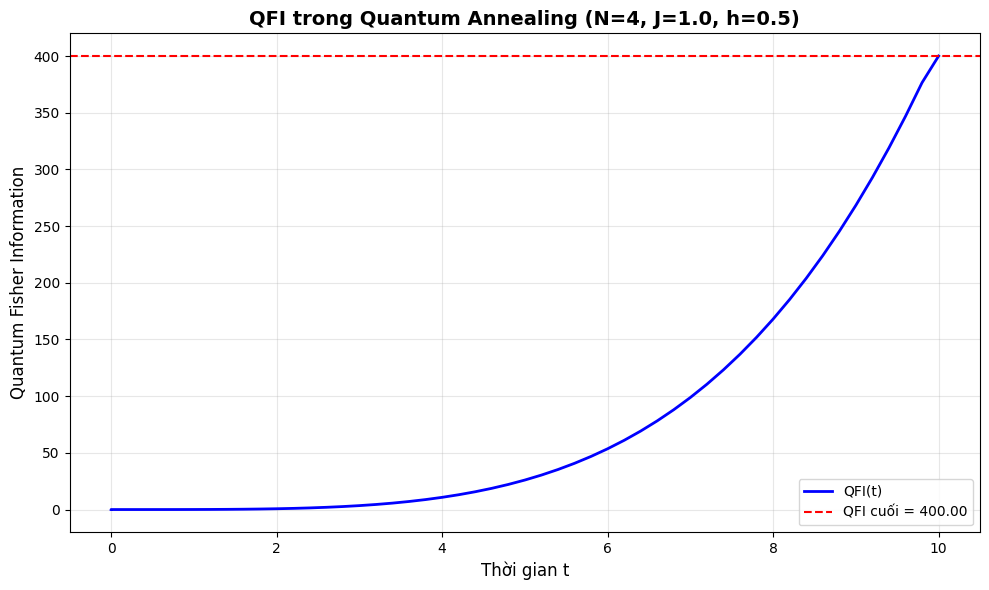


HOÀN THÀNH!


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, eigh

class QuantumFisherIsing:
    """
    Tính Quantum Fisher Information cho Ising chain sensor
    trong quá trình quantum annealing
    """

    def __init__(self, N, J=1.0):
        """
        Parameters:
        -----------
        N : int - Số spin trong chuỗi
        J : float - Cường độ tương tác Ising
        """
        self.N = N
        self.J = J
        self.dim = 2**N

        # Xây dựng các toán tử Pauli
        self.X = np.array([[0, 1], [1, 0]], dtype=complex)
        self.Z = np.array([[1, 0], [0, -1]], dtype=complex)
        self.I = np.eye(2, dtype=complex)

        # Xây dựng Hamiltonian và toán tử
        self.Hd = self._build_Hd()
        self.X_sum = self._build_X_sum()

        # Tìm trạng thái cơ bản
        self.psi0 = self._ground_state()

    def _kron_list(self, op_list):
        """Tính tích Kronecker của danh sách toán tử"""
        result = op_list[0]
        for op in op_list[1:]:
            result = np.kron(result, op)
        return result

    def _build_single_site_op(self, j, pauli):
        """Xây dựng toán tử Pauli tác động lên site j"""
        op_list = [self.I] * self.N
        op_list[j] = pauli
        return self._kron_list(op_list)

    def _build_Hd(self):
        """Xây dựng H_d = J * sum_{j} Z_j Z_{j+1}"""
        Hd = np.zeros((self.dim, self.dim), dtype=complex)

        for j in range(self.N - 1):
            # Z_j
            Zj = self._build_single_site_op(j, self.Z)
            # Z_{j+1}
            Zj1 = self._build_single_site_op(j+1, self.Z)
            # Cộng J * Z_j Z_{j+1}
            Hd += self.J * (Zj @ Zj1)

        return Hd

    def _build_X_sum(self):
        """Xây dựng X_sum = sum_{j} X_j"""
        X_sum = np.zeros((self.dim, self.dim), dtype=complex)

        for j in range(self.N):
            X_sum += self._build_single_site_op(j, self.X)

        return X_sum

    def _ground_state(self):
        """Tìm trạng thái cơ bản của H_d"""
        eigenvalues, eigenvectors = eigh(self.Hd)
        # Trạng thái cơ bản = eigenvector ứng với eigenvalue nhỏ nhất
        ground_state = eigenvectors[:, 0]
        return ground_state

    def schedule(self, t, T, alpha=2.0):
        """
        Lịch trình annealing
        s(t) = (t/T)^alpha
        A(t) = 1 - s(t)
        B(t) = s(t)
        """
        s = (t / T) ** alpha
        A = 1 - s
        B = s
        return A, B

    def build_H(self, t, h, T, alpha=2.0):
        """Xây dựng Hamiltonian tại thời điểm t"""
        A, B = self.schedule(t, T, alpha)
        H = A * self.Hd + B * h * self.X_sum
        return H

    def evolve_step(self, psi, H, dt):
        """Tiến hóa trạng thái qua 1 bước thời gian nhỏ"""
        # Sử dụng evolution operator U = exp(-i H dt)
        # (đơn vị: ℏ = 1)
        U = expm(-1j * H * dt)
        return U @ psi

    def compute_QFI(self, h, T, alpha=2.0, dt=0.01, return_trajectory=False):
        """
        Tính Quantum Fisher Information

        Parameters:
        -----------
        h : float - Tham số từ trường cần ước lượng
        T : float - Thời gian annealing tổng
        alpha : float - Tham số lịch trình
        dt : float - Bước thời gian
        return_trajectory : bool - Có trả về QFI theo thời gian không

        Returns:
        --------
        QFI_final : float - QFI tại thời điểm cuối
        (optional) times, QFI_trajectory
        """

        # Khởi tạo
        psi = self.psi0.copy()
        G = np.zeros((self.dim, self.dim), dtype=complex)

        # Danh sách để lưu궤적
        times = [0]
        QFI_trajectory = [0]

        # Time evolution
        K = int(T / dt)

        for k in range(K):
            t = k * dt
            t_mid = t + dt/2

            # Hamiltonian tại midpoint
            H_mid = self.build_H(t_mid, h, T, alpha)

            # Tiến hóa psi
            psi_new = self.evolve_step(psi, H_mid, dt)

            # Tính đạo hàm của H theo h: dH/dh = B(t) * X_sum
            A_mid, B_mid = self.schedule(t_mid, T, alpha)
            dH_dh = B_mid * self.X_sum

            # Evolution operator đến thời điểm t
            # Cần tạo U_h(t, 0) - đơn giản hóa: dùng psi hiện tại

            # Tính toán trong interaction picture:
            # U^†(t,0) * dH/dh * U(t,0) |psi0>
            # Xấp xỉ: dH_dh tác động lên psi hiện tại

            # Tích lũy generator
            G += dH_dh * dt

            # Tính QFI tại thời điểm này nếu cần
            if return_trajectory and (k % max(1, K//50) == 0):
                QFI_t = self._compute_QFI_from_generator(G)
                times.append(t)
                QFI_trajectory.append(QFI_t)

            psi = psi_new

        # Tính QFI cuối cùng
        QFI_final = self._compute_QFI_from_generator(G)

        if return_trajectory:
            times.append(T)
            QFI_trajectory.append(QFI_final)
            return QFI_final, np.array(times), np.array(QFI_trajectory)
        else:
            return QFI_final

    def _compute_QFI_from_generator(self, G):
        """
        Tính QFI từ generator G
        F_Q = 4 * (⟨ψ0|G²|ψ0⟩ - |⟨ψ0|G|ψ0⟩|²)
        """
        psi0 = self.psi0

        # ⟨ψ0|G|ψ0⟩
        G_expectation = np.vdot(psi0, G @ psi0)

        # ⟨ψ0|G²|ψ0⟩
        G2_expectation = np.vdot(psi0, G @ G @ psi0)

        # Variance
        variance = G2_expectation - abs(G_expectation)**2

        # QFI
        QFI = 4 * variance.real

        return QFI


# ============= CHƯƠNG TRÌNH CHÍNH =============

def main():
    """Chương trình demo"""

    # Tham số hệ thống
    N = 4           # Số spin
    J = 1.0         # Tương tác Ising
    h = 0.5         # Từ trường cần ước lượng
    T = 10.0         # Thời gian annealing
    alpha = 1.0     # Tham số lịch trình
    dt = 0.05       # Bước thời gian

    print("="*60)
    print("QUANTUM FISHER INFORMATION - ISING CHAIN SENSOR")
    print("="*60)
    print(f"Số spin (N): {N}")
    print(f"Tương tác (J): {J}")
    print(f"Từ trường (h): {h}")
    print(f"Thời gian annealing (T): {T}")
    print(f"Tham số lịch trình (α): {alpha}")
    print(f"Bước thời gian (dt): {dt}")
    print("="*60)

    # Khởi tạo hệ thống
    print("\n[1] Xây dựng hệ thống...")
    system = QuantumFisherIsing(N, J)
    print(f"    Không gian Hilbert: {system.dim} chiều")
    print(f"    Năng lượng trạng thái cơ bản: {np.vdot(system.psi0, system.Hd @ system.psi0).real:.4f}")

    # Tính QFI
    print("\n[2] Tính Quantum Fisher Information...")
    QFI_final, times, QFI_trajectory = system.compute_QFI(
        h, T, alpha, dt, return_trajectory=True
    )

    print(f"    QFI cuối cùng: {QFI_final:.4f}")
    print(f"    QFI tối đa: {np.max(QFI_trajectory):.4f}")
    print(f"    QFI trung bình: {np.mean(QFI_trajectory):.4f}")

    # Vẽ đồ thị
    print("\n[3] Vẽ đồ thị kết quả...")
    plt.figure(figsize=(10, 6))
    plt.plot(times, QFI_trajectory, 'b-', linewidth=2, label='QFI(t)')
    plt.axhline(y=QFI_final, color='r', linestyle='--',
                label=f'QFI cuối = {QFI_final:.2f}')
    plt.xlabel('Thời gian t', fontsize=12)
    plt.ylabel('Quantum Fisher Information', fontsize=12)
    plt.title(f'QFI trong Quantum Annealing (N={N}, J={J}, h={h})',
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('qfi_trajectory.png', dpi=150)
    print("    Đã lưu đồ thị: qfi_trajectory.png")
    plt.show()

    print("\n" + "="*60)
    print("HOÀN THÀNH!")
    print("="*60)


if __name__ == "__main__":
    main()

In [38]:
#!/usr/bin/env python3
"""
qa_qfi_solver.py

Mô tả:
    - Xây Pauli trên N qubit
    - Xây Hd = J * sum Z_j Z_{j+1} (open boundary)
    - Xsum = sum X_j
    - Tìm ground state của Hd
    - Evolve bằng U(t+dt, t) = exp(-i H_mid dt) (midpoint)
    - Tích lũy G_h(T) ≈ sum_k U(t_k,0)^\dagger * B(t_k) Xsum * U(t_k,0) * dt
    - Tính F_Q(T) = 4 (⟨Gh^2⟩ - |⟨Gh⟩|^2 ) với trạng thái ban đầu |ψ0⟩ (ground state của Hd)
"""

import numpy as np
from scipy.linalg import expm, eigh
import time

# ----------------------
# Pauli cơ bản
# ----------------------
I2 = np.array([[1.,0.],[0.,1.]], dtype=complex)
X2 = np.array([[0.,1.],[1.,0.]], dtype=complex)
Y2 = np.array([[0.,-1j],[1j,0.]], dtype=complex)
Z2 = np.array([[1.,0.],[0.,-1.]], dtype=complex)

def kron_n(op_list):
    """Kronecker product của list các ma trận (trái -> phải)."""
    out = op_list[0]
    for M in op_list[1:]:
        out = np.kron(out, M)
    return out

def pauli_on_site(pauli, site, N):
    """Trả về ma trận Pauli trên hệ N qubit, với pauli in {I2,X2,Y2,Z2} ở vị trí site (0-based)."""
    ops = []
    for i in range(N):
        ops.append(pauli if i == site else I2)
    return kron_n(ops)

def sum_pauli(pauli):
    """Trả về hàm xây operator sum pauli_j = sum_j pauli_j (phụ thuộc N được truyền khi gọi)"""
    raise RuntimeError("Không dùng.")

# ----------------------
# Xây Hamiltonians
# ----------------------
def build_Hd(N, J=1.0):
    """Hd = J * sum_{j=1}^{N-1} Z_j Z_{j+1} (open boundary)"""
    dim = 2**N
    Hd = np.zeros((dim, dim), dtype=complex)
    for j in range(N-1):
        Zj = pauli_on_site(Z2, j, N)
        Zjp1 = pauli_on_site(Z2, j+1, N)
        Hd += np.dot(Zj, Zjp1)
    Hd *= J
    return Hd

def build_Xsum(N):
    """Xsum = sum_j X_j"""
    dim = 2**N
    Xsum = np.zeros((dim, dim), dtype=complex)
    for j in range(N):
        Xsum += pauli_on_site(X2, j, N)
    return Xsum

# ----------------------
# Schedule A(t), B(t) with s(t) = (t/T)^alpha
# ----------------------
def s_of_t(t, T, alpha):
    if T == 0:
        return 1.0
    return (t / T) ** alpha

def A_of_t(t, T, alpha):
    return 1.0 - s_of_t(t, T, alpha)

def B_of_t(t, T, alpha):
    return s_of_t(t, T, alpha)

# ----------------------
# Core routine: compute Gh and FQ
# ----------------------
def compute_QFI(N, J, h, T, K, alpha=1.0, compute_intermediate_FQ=False, store_times=None, verbose=True):
    """
    Tham số:
        N: số qubit
        J: coupling trong Hd
        h: tham số cần ước lượng (coupled to Xsum)
        T: total anneal time
        K: số bước time grid (K dt = T)
        alpha: exponent trong s(t) = (t/T)^alpha
        compute_intermediate_FQ: nếu True, tính FQ(t) cho store_times list (giá trị times phải thuộc grid)
        store_times: list các thời điểm (float) muốn lấy FQ(t); nếu None -> không tính
    Trả về:
        FQ_T: float (QFI tại T)
        result_dict: chứa Gh (ma trận), psi0, optional FQ_t list
    """
    dt = T / K
    dim = 2**N

    if verbose:
        print(f"Running QFI computation: N={N}, dim={dim}, K={K}, dt={dt:.4e}, T={T}, J={J}, h={h}, alpha={alpha}")

    # Build Hamiltonians
    if verbose: print("Building Hd and Xsum ...")
    Hd = build_Hd(N, J=J)
    Xsum = build_Xsum(N)

    # Ground state of Hd
    if verbose: print("Diagonalizing Hd to get ground state ...")
    Evals, Evecs = eigh(Hd)
    idx0 = np.argmin(Evals)
    E0 = Evals[idx0]
    psi0 = Evecs[:, idx0]   # column vector (dim,)
    if verbose: print(f"Ground energy E0 = {E0:.6f}")

    # Initialize
    U = np.eye(dim, dtype=complex)   # U(t=0,0)
    Gh = np.zeros((dim, dim), dtype=complex)

    # For optionally computing FQ(t) at intermediate times:
    FQ_times = {}
    store_set = set(store_times) if store_times is not None else set()

    # Time stepping: use tk = k*dt (k=0...K-1) for Riemann sum terms,
    # but use midpoint Hamiltonian at t_mid = tk + dt/2 for evolution step.
    t = 0.0
    for k in range(K):
        tk = k * dt
        # Term for Gh: use U(tk,0) (current U), B(tk), Xsum
        Btk = B_of_t(tk, T, alpha)
        term = U.conj().T @ ( (Btk * Xsum) @ U )   # U^\dagger * B(tk)*Xsum * U
        Gh += term * dt

        # If user wants FQ(t) at times matching tk (after accumulating up to tk)
        if compute_intermediate_FQ and (tk in store_set):
            mean = np.vdot(psi0, (Gh @ psi0))  # <psi0|Gh|psi0>
            mean2 = np.vdot(psi0, (Gh @ (Gh @ psi0)))  # <psi0|Gh^2|psi0>
            FQ_here = 4.0 * (mean2 - abs(mean)**2)
            FQ_times[tk] = np.real_if_close(FQ_here)

        # Now evolve U from tk -> tk+dt using midpoint Hamiltonian:
        t_mid = tk + 0.5 * dt
        A_mid = A_of_t(t_mid, T, alpha)
        B_mid = B_of_t(t_mid, T, alpha)
        H_mid = A_mid * Hd + B_mid * h * Xsum

        # small optimization: if dt very small and H_mid Hermitian, use expm directly
        U_step = expm(-1j * H_mid * dt)
        U = U_step @ U

        t += dt

    # After loop, Gh is approximated
    # Compute FQ(T)
    mean = np.vdot(psi0, (Gh @ psi0))
    mean2 = np.vdot(psi0, (Gh @ (Gh @ psi0)))
    FQ_T = 4.0 * (mean2 - abs(mean)**2)
    FQ_T = np.real_if_close(FQ_T)

    result = {
        "Gh": Gh,
        "psi0": psi0,
        "Hd": Hd,
        "Xsum": Xsum,
        "FQ_T": np.real_if_close(FQ_T),
        "FQ_times": FQ_times
    }
    return np.real_if_close(FQ_T), result

# ----------------------
# Example run
# ----------------------
if __name__ == "__main__":
    # Tham số bạn có thể chỉnh
    N = 4          # số spin
    J = 1.0
    h = 0.5
    T = 10.0
    K = 200        # số bước (tăng K để chính xác hơn)
    alpha = 1.0    # schedule exponent

    t0 = time.time()
    FQ_T, res = compute_QFI(N=N, J=J, h=h, T=T, K=K, alpha=alpha, compute_intermediate_FQ=False)
    t1 = time.time()

    print("\n--- Result ---")
    print(f"QFI at T = {T} is F_Q = {FQ_T:.8e}")
    print(f"Elapsed time: {t1-t0:.3f} s")
    print("Notes:")
    print(" - Increase K for better Riemann sum accuracy.")
    print(" - For larger N, consider sparse methods or Trotterization / Krylov exponentiation.")


Running QFI computation: N=4, dim=16, K=200, dt=5.0000e-02, T=10.0, J=1.0, h=0.5, alpha=1.0
Building Hd and Xsum ...
Diagonalizing Hd to get ground state ...
Ground energy E0 = -3.000000

--- Result ---
QFI at T = 10.0 is F_Q = 6.07827968e+01
Elapsed time: 0.038 s
Notes:
 - Increase K for better Riemann sum accuracy.
 - For larger N, consider sparse methods or Trotterization / Krylov exponentiation.


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\anhduy.truong\AppData\Local\Temp\ipykernel_27480\2480318902.py:2: SyntaxWarning: invalid escape sequence '\d'
  """
